# Day 08. Exercise 01
# Binary classifier. SVM. Decision tree

## 0. Imports

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder # перевести значения из object в числа

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.tree import plot_tree

## 1. Preprocessing and logreg visualization

Read the file `am_pm.csv` to a dataframe from the previous exercise.

1. Draw a plot where the x-axis is `am`, the y-axis is `pm`, dots are the days, color depends on the target.
2. Add the decision boundary of logistic regression to the plot.
3. Draw the same plot (with the boundary), but the color should depend this time on the predictions.

Now it should be clear for you how the logistic regression works.

In [85]:
df = pd.read_csv('../data/am_pm.csv', parse_dates = ['date'])

In [86]:
X = df[['am', 'pm']]
y = df['target']

In [87]:
model = LogisticRegression(random_state=21, fit_intercept=False)

In [88]:
model.fit(X,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,False
,intercept_scaling,1
,class_weight,None
,random_state,21
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [89]:
coef_am, coef_pm = model.coef_[0]
print(coef_am, coef_pm)

# Логистическая регрессия в двумерном случае ищет уравнение вида: coef_am * am + coef_pm * pm = 0
# Это уравнение прямой (граница между классами).

-0.0003865266152771011 0.002980657390742416


In [90]:
am = np.linspace(df['am'].min(), df['am'].max(), 100)
pm = -(coef_am / coef_pm) * am

# уравнение прямой: coef_am*am + coef_pm*pm = 0

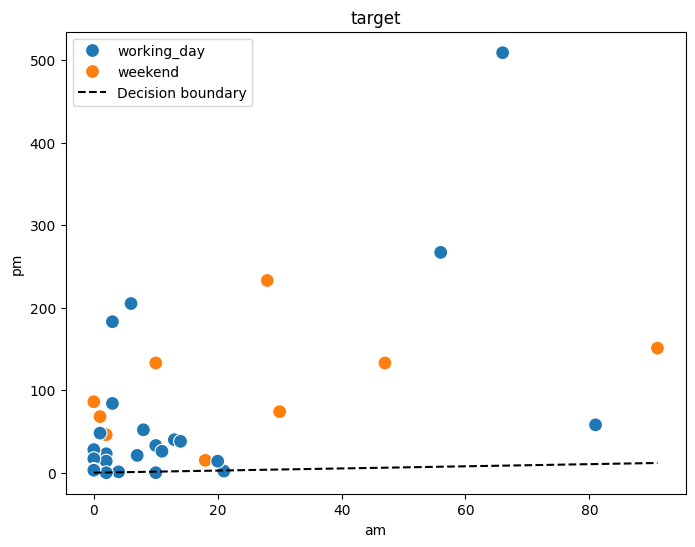

In [91]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='am', y='pm', hue='target', s=100)
plt.plot(am, pm, color='black', linestyle='--', label='Decision boundary')
plt.title("target")
plt.legend()
plt.show()

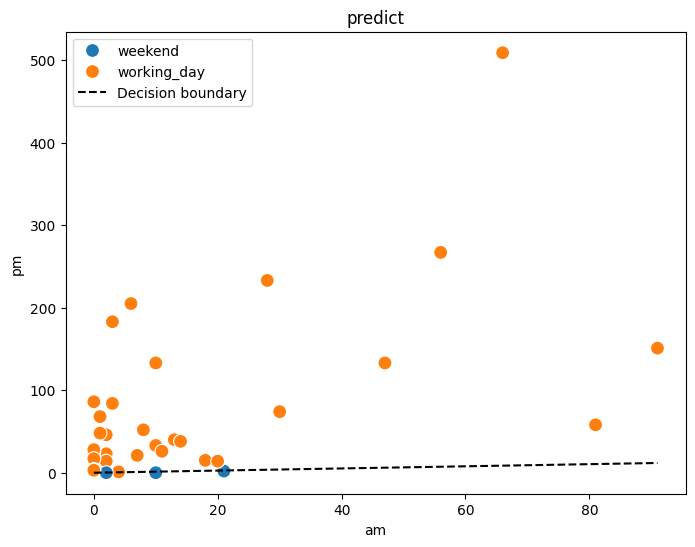

In [92]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='am', y='pm', hue='predict', s=100)
plt.plot(am, pm, color='black', linestyle='--', label='Decision boundary')
plt.title("predict")
plt.legend()
plt.show()

## 2. Standardizing and logreg

Linear models can be sensitive to the scale of your variables. You make it easier for them to find the optimal solution when you scale your features.

1. Apply `StandardScaler` to `X` and train logistic regression again with the same parameters.
2. Calculate `accuracy` for the new model. Did it get better than a naive classifier with the most popular class?
3. Draw the plots that were described above but for the new model.

Standartscaler превращает каждый признак в "z-оценку": $\frac{x - mean}{std}$
- признаки становятся безразмерными, со средним 0 и стандартным отклонением 1.

In [93]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [94]:
model = LogisticRegression(random_state=21, fit_intercept=False)

Модель теперь обучается не на исходных am и pm, а на их стандартизированных версиях: 

$coef_{am} * z_{am} + coef_{pm} * z_{pm} = 0$

$z_{am} = \frac{am - mean_{am}}{std_{am}}$

$z_{pm} = \frac{pm - mean_{pm}}{std_{pm}}$

$coef_{am} * \frac{am - mean_{am}}{std_{am}} + coef_{pm} * \frac{pm - mean_{pm}}{std_{pm}} = 0$

In [95]:
model.fit(X_scaled, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,False
,intercept_scaling,1
,class_weight,None
,random_state,21
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [96]:
y_pred = model.predict(X_scaled)
y_true = df['target']

accuracy_score(y_pred, y_true)

0.7428571428571429

$coef_{am} * \frac{am - mean_{am}}{std_{am}} + coef_{pm} * \frac{pm - mean_{pm}}{std_{pm}} = 0$

$pm = - \frac{coef_{am} * std_{pm}}{coef_{pm} * std_{am}} * (am - mean_{am}) + mean_{pm}$

In [97]:
coef_am, coef_pm = model.coef_[0]
mean_am, mean_pm = scaler.mean_
std_am, std_pm = scaler.scale_

z_am = np.linspace(df['am'].min(), df['am'].max(), 100)   # ось Х
z_pm = - (coef_am / coef_pm) * (std_pm / std_am) * (z_am - mean_am) + mean_pm  # ось Y

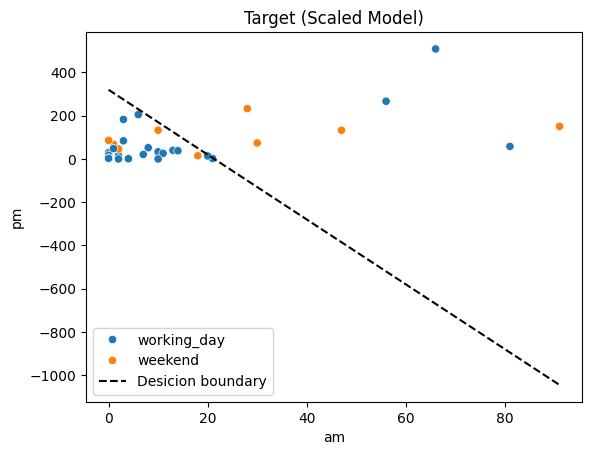

In [98]:
plt.Figure(figsize=(12,8))
sns.scatterplot(data=df, x = 'am', y = 'pm', hue = df['target'])
plt.plot(z_am, z_pm, color = 'black', linestyle = '--', label = 'Desicion boundary')
plt.title('Target (Scaled Model)')
plt.legend()

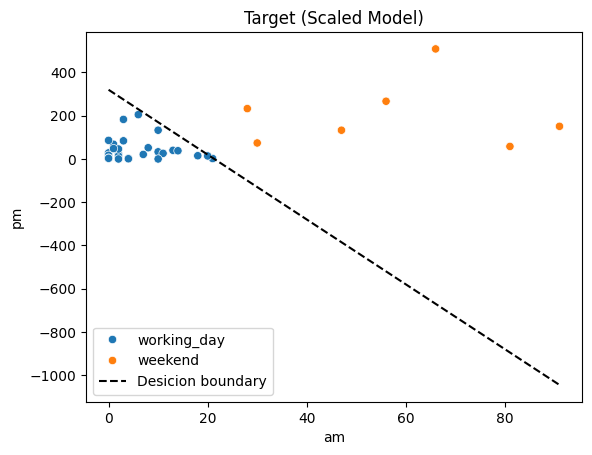

In [99]:
plt.Figure(figsize=(12,8))
sns.scatterplot(data=df, x = 'am', y = 'pm', hue = y_pred)
plt.plot(z_am, z_pm, color = 'black', linestyle = '--', label = 'Desicion boundary')
plt.title('Target (Scaled Model)')
plt.legend()

### Yes, it get better than a naive classifier with the most popular class

## 3. SVM

1. Apply `SVC` model to the scaled dataframe using parameters `probability=True`, `random_state=21`.
2. Calculate `accuracy`.
3. Try different kernels, find the best in terms of accuracy.
4. Draw both plots again with the decisions boundary to see how this algorithm works.

In [100]:
model = SVC(kernel='rbf', probability=True, random_state=21)
# SVC(probability=True) - Модель обучается дополнительно для оценки вероятностей. Можно получать вероятности через .predict_proba()

model.fit(X_scaled, y)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [101]:
y_pred = model.predict(X_scaled)
y_true = df['target']
accuracy_score(y_pred, y_true)

0.7428571428571429

In [102]:
model.fit(X_scaled, LabelEncoder().fit_transform(y))

# Диапазон x, y
am_min = df['am'].min() - 5
am_max = df['am'].max() + 5

pm_min = df['pm'].min() - 5
pm_max = df['pm'].max() + 5

In [103]:
am_grid, pm_grid = np.meshgrid(
    np.linspace(am_min, am_max, 200),
    np.linspace(pm_min, pm_max, 200)
)

# np.meshgrid создаёт две двумерные матрицы координат — как бумага в клетку (200×200 точек)
# каждая клетка на этом поле — потенциальная точка данных, где модель может сделать предсказание

In [104]:
grid_points = np.c_[am_grid.ravel(), pm_grid.ravel()]

# ravel() - превращает двумерную матрицу X-координат в одномерный список.
# np.c_[] -  "склеивает" x y столбцами в массив -> все возможные точки на сетке

In [105]:
# Маштабирование точек

grid_scaler = scaler.transform(grid_points)

c:\Users\Анастасия\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


- model.predict(grid_scaled) возвращает 40 000 предсказаний классов (по одному для каждой точки).
Например, 'working_day' или 'weekend'.

- Затем Z.reshape(am_grid.shape) возвращает их обратно в форму 200×200,
чтобы соответствовало сетке координат.

In [106]:
Z = model.predict(grid_scaler)
Z = Z.reshape(am_grid.shape)

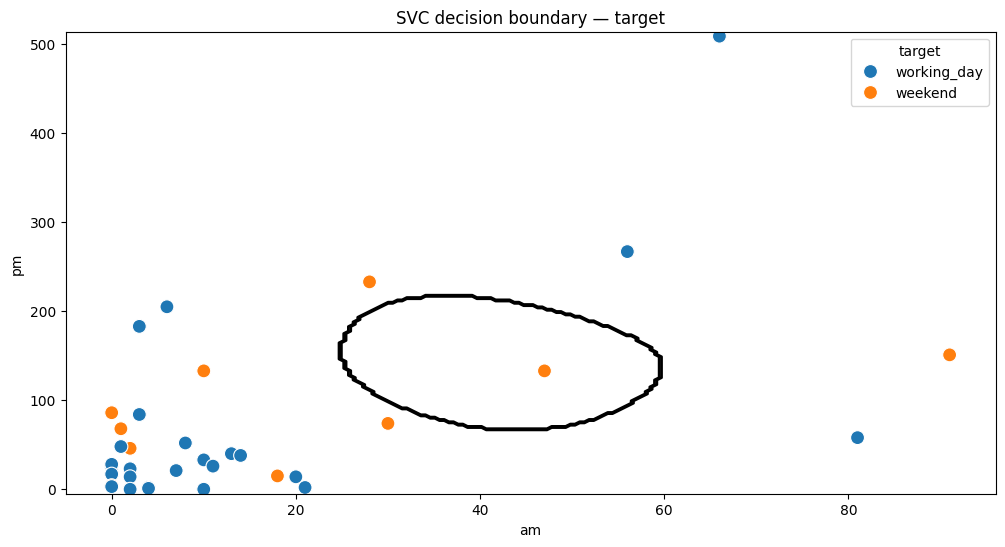

In [107]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='am', y='pm', hue='target', s=100)
plt.contour(am_grid, pm_grid, Z, levels=1, linewidths=2, colors='black')
plt.title("SVC decision boundary — target")
plt.show()

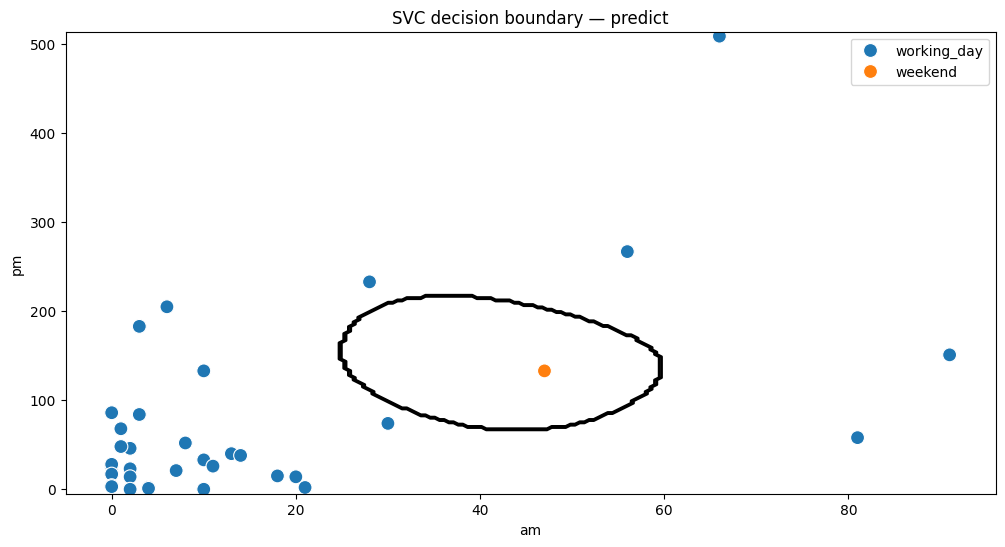

In [108]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='am', y='pm', hue=y_pred, s=100)
plt.contour(am_grid, pm_grid, Z, levels=1, linewidths=2, colors='black')
plt.title("SVC decision boundary — predict")
plt.show()

## 4. Decision tree

1. Apply `DecisionTreeClassifier` to the scaled dataframe using parameters `max_depth=4`, `random_state=42`.
2. Calculate accuracy.
3. Try different values of `max_depth`.
4. Draw both plots again with the decisions boundary to see how this algorithm works.
5. Using method `.plot_tree()` visualize the decision tree itself. It is another way of thinking about how the algorithm works.
6. How many leaves in the visualized tree label days as working days? Put your answer in the markdown cell in the end of the section.

In [127]:
model = DecisionTreeClassifier(max_depth=4,random_state=42)
model.fit(X_scaled, y)

y_pred = model.predict(X_scaled)
accuracy_score(y_pred, y_true)

0.9428571428571428

In [128]:
for depth in range(1, 8):
    tree_1 = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree_1.fit(X_scaled, y)
    y_pred = tree_1.predict(X_scaled)
    print(f"Depth={depth}, Accuracy={accuracy_score(y_pred, y_true):.3f}")

Depth=1, Accuracy=0.771
Depth=2, Accuracy=0.857
Depth=3, Accuracy=0.886
Depth=4, Accuracy=0.943
Depth=5, Accuracy=0.971
Depth=6, Accuracy=1.000
Depth=7, Accuracy=1.000


In [129]:
model.fit(X_scaled, LabelEncoder().fit_transform(y))

am_min, am_max = df['am'].min() - 5, df['am'].max() + 5
pm_min, pm_max = df['pm'].min() - 5, df['pm'].max() + 5

am_grid, pm_grid = np.meshgrid(
    np.linspace(am_min, am_max, 200),
    np.linspace(pm_min, pm_max, 200)
)

grid_points = np.c_[am_grid.ravel(), pm_grid.ravel()]
grid_scaled = scaler.transform(grid_points)

Z = model.predict(grid_scaled)
Z = Z.reshape(am_grid.shape)


c:\Users\Анастасия\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


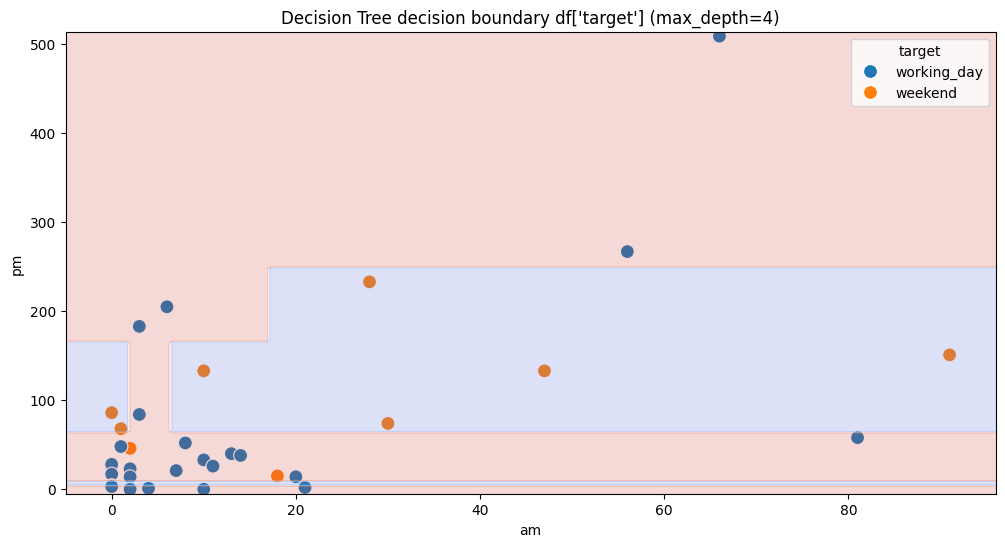

In [130]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='am', y='pm', hue='target', s=100)
plt.contourf(am_grid, pm_grid, Z, alpha=0.2, cmap='coolwarm')
plt.title("Decision Tree decision boundary df['target'] (max_depth=4)")
plt.show()

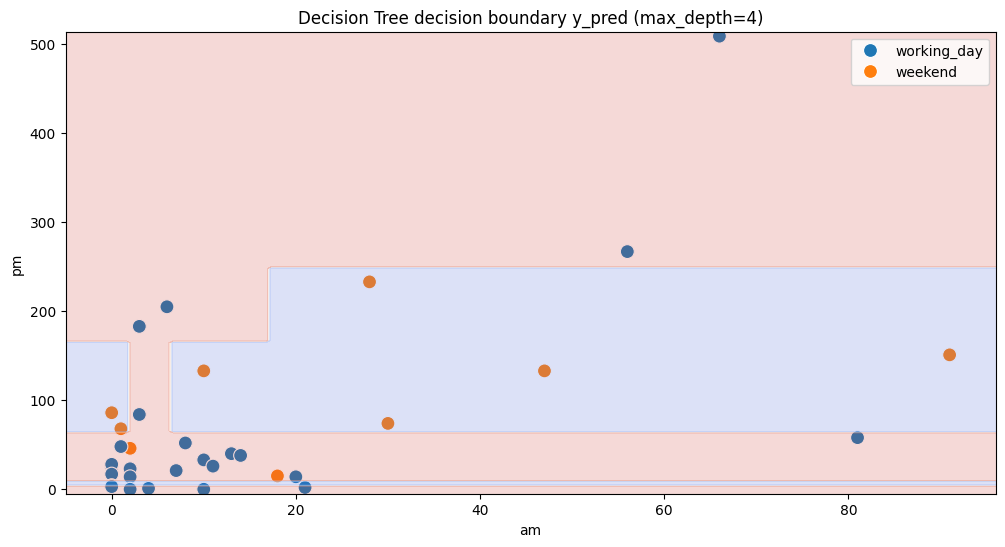

In [131]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='am', y='pm', hue=y_pred, s=100)
plt.contourf(am_grid, pm_grid, Z, alpha=0.2, cmap='coolwarm')
plt.title("Decision Tree decision boundary y_pred (max_depth=4)")
plt.show()

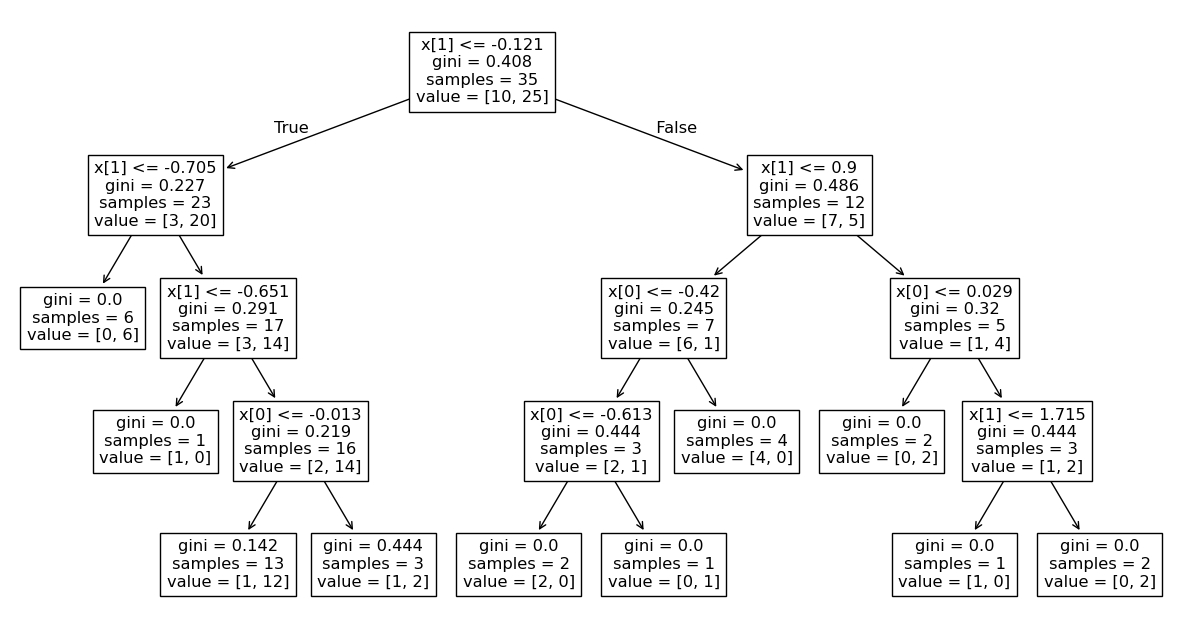

In [132]:
plt.figure(figsize=(15, 8))
tree.plot_tree(model)
plt.show()

### 4